In [ ]:
# =============================================================================
# CONGRESSIONAL INSIDER TRADING — EXPLORATORY DATA ANALYSIS
# =============================================================================
# This notebook performs a full exploratory analysis of the U.S. Senate
# STOCK Act disclosure dataset before any machine learning is applied.
# The goal is to understand the structure of the data, identify quality issues,
# and surface initial patterns that motivate the downstream modelling choices.
# =============================================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro

# Apply a consistent visual style across all plots
sns.set_theme(style="whitegrid", palette="muted")

# Load the raw disclosure dataset
# The processed version with alpha is loaded later where alpha-specific
# analyses require it; here we start from the raw source
df = pd.read_csv('senate_stock_discosures.csv')



# Convert the transaction date to datetime format for proper time-series analysis
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year']  = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month

# Display the top 5 senators by transaction volume
print("--- Top 5 Senators by Transaction Volume ---")
print(df['last_name'].value_counts().head(5))

# Display the top 5 most traded tickers
print("\n--- Top 5 Traded Tickers ---")
print(df['ticker'].value_counts().head(5))


--- Top 5 Senators by Transaction Volume ---
last_name
Tuberville    1094
Capito         571
Whitehouse     532
Carper         499
Wyden          255
Name: count, dtype: int64

--- Top 5 Traded Tickers ---
ticker
AAPL    109
MSFT     94
CLF      91
PYPL     63
INTC     62
Name: count, dtype: int64


DATASET SHAPE
Rows    : 4,699
Columns : 14

COLUMN TYPES AND NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4699 entries, 0 to 4698
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ticker              4699 non-null   object        
 1   asset_name          4699 non-null   object        
 2   asset_type          4699 non-null   object        
 3   stock_price         4699 non-null   float64       
 4   transaction         4699 non-null   object        
 5   transaction_date    4699 non-null   datetime64[ns]
 6   asset_value_low     4699 non-null   int64         
 7   asset_value_high    4699 non-null   int64         
 8   last_name           4699 non-null   object        
 9   first_name          4699 non-null   object        
 10  owner               4699 non-null   object        
 11  additional_details  4699 non-null   object        
 12  year                4699 no

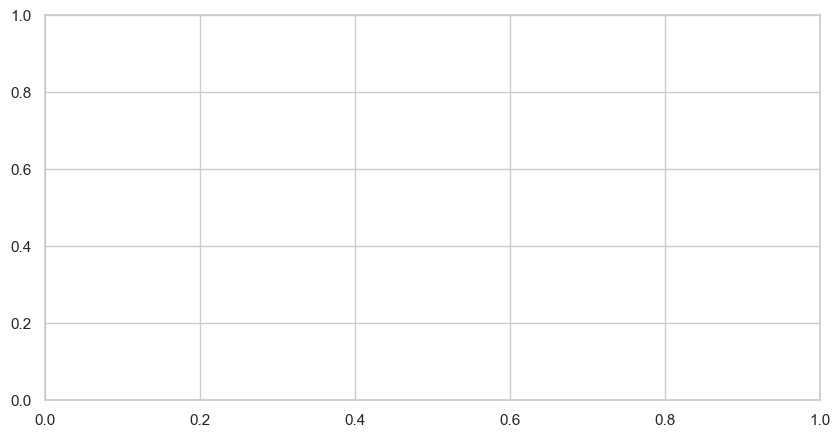

In [3]:
# =============================================================================
# Before any analysis, we must understand what the dataset actually contains.
# This cell answers three structural questions:
#   1. How large is the dataset and what columns does it have?
#   2. What are the data types and are they correct?
#   3. Where is data missing and how much?
#
# Missing values are particularly important here: a ticker with no value
# cannot contribute to alpha computation, and a senator with no transaction
# date cannot be placed on a timeline. We need to know the scale of these
# gaps before trusting any downstream aggregate statistics.
# =============================================================================

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 60)
print("COLUMN TYPES AND NON-NULL COUNTS")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)")
print("=" * 60)
print(df.describe().T.to_string())

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report[missing_report['Missing Count'] > 0].to_string())

# Visualize the missing-value pattern
fig, ax = plt.subplots(figsize=(10, 5))
missing_nonzero = missing[missing > 0]
if not missing_nonzero.empty:
    colors = ['#E24B4A' if pct > 10 else '#EF9F27'
              for pct in missing_pct[missing_nonzero.index]]
    bars = ax.barh(missing_nonzero.index, missing_nonzero.values,
                   color=colors, edgecolor='white', height=0.6)
    ax.bar_label(bars, labels=[f'{v:,} ({missing_pct[i]:.1f}%)'
                               for i, v in zip(missing_nonzero.index, missing_nonzero.values)],
                 padding=5, fontsize=10)
    ax.set_xlabel('Number of missing values')
    ax.set_title('Missing Values by Column', fontweight='bold', fontsize=13)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

print("\n[Sample rows]")
print(df.head(5).to_string())


--- STEP: DISTRIBUTION OF KEY CATEGORICAL VARIABLES ---


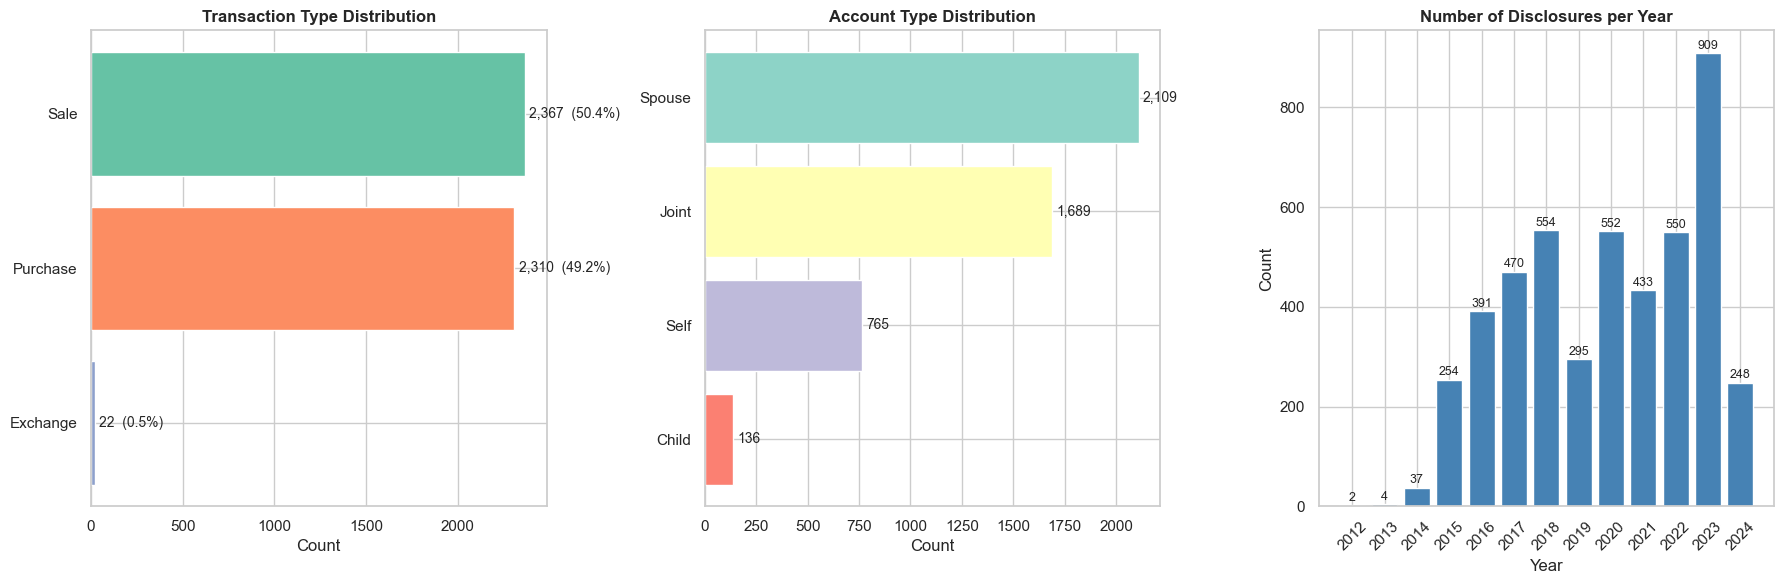


Self-directed transactions : 765
Proxy-account transactions : 3,934
Proxy share               : 83.7%


In [4]:
# =============================================================================
# Three structural distributions shape every downstream analysis:
#
#   1. Transaction type (Purchase / Sale / Exchange) — sets the class balance
#      for the supervised model and determines the direction of alpha inference.
#
#   2. Account type (Self / Spouse / Joint / Dependent) — the proxy-account
#      hypothesis rests on this column being meaningful and populated.
#
#   3. Yearly activity — the STOCK Act was passed in 2012; we expect a
#      reporting surge shortly after. COVID-19 (2020) and the associated
#      market volatility may also produce a spike. Understanding the temporal
#      distribution helps us assess whether year is a confounding variable.
# =============================================================================

print("\n--- STEP: DISTRIBUTION OF KEY CATEGORICAL VARIABLES ---")

# Standardize transaction labels: consolidate minor variants (e.g. "Sale (Full)")
df['transaction_clean'] = df['transaction'].astype(str).str.split('(').str[0].str.strip()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Transaction type breakdown
tx_counts = df['transaction_clean'].value_counts()
axes[0].barh(tx_counts.index, tx_counts.values,
             color=sns.color_palette('Set2', len(tx_counts)), edgecolor='white')
for i, (idx, val) in enumerate(tx_counts.items()):
    axes[0].text(val + max(tx_counts) * 0.01, i,
                 f'{val:,}  ({100*val/len(df):.1f}%)', va='center', fontsize=10)
axes[0].set_title('Transaction Type Distribution', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Plot 2: Account / owner type
owner_counts = df['owner'].fillna('Unknown').value_counts().head(8)
axes[1].barh(owner_counts.index, owner_counts.values,
             color=sns.color_palette('Set3', len(owner_counts)), edgecolor='white')
for i, (idx, val) in enumerate(owner_counts.items()):
    axes[1].text(val + max(owner_counts) * 0.01, i,
                 f'{val:,}', va='center', fontsize=10)
axes[1].set_title('Account Type Distribution', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

# Plot 3: Yearly trading activity
year_counts = df['year'].value_counts().sort_index()
axes[2].bar(year_counts.index.astype(str), year_counts.values,
            color='steelblue', edgecolor='white')
axes[2].set_title('Number of Disclosures per Year', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
for i, (yr, val) in enumerate(year_counts.items()):
    axes[2].text(i, val + max(year_counts) * 0.01, str(val),
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Numeric summary of the proxy-account breakdown
proxy_mask = df['owner'].fillna('').str.contains('Spouse|Joint|Child', case=False)
print(f"\nSelf-directed transactions : {(~proxy_mask).sum():,}")
print(f"Proxy-account transactions : {proxy_mask.sum():,}")
print(f"Proxy share               : {100*proxy_mask.mean():.1f}%")

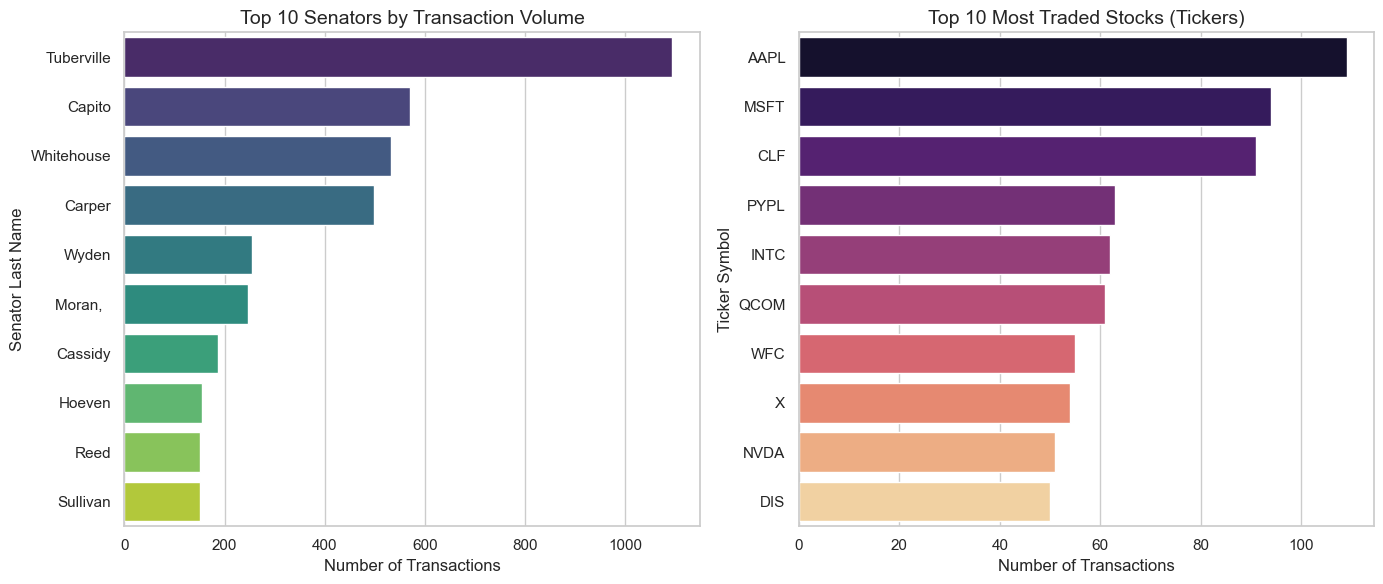

In [5]:
# Configure general aesthetics for the plots
plt.figure(figsize=(14, 6))

# Plot 1: Top 10 Senators by transaction count
plt.subplot(1, 2, 1)
top_senators = df['last_name'].value_counts().head(10)
sns.barplot(x=top_senators.values, y=top_senators.index, hue=top_senators.index,
            legend=False, palette='viridis')
plt.title('Top 10 Senators by Transaction Volume', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Senator Last Name', fontsize=12)

# Plot 2: Top 10 Tickers by transaction count
plt.subplot(1, 2, 2)
top_tickers = df['ticker'].value_counts().head(10)
sns.barplot(x=top_tickers.values, y=top_tickers.index, hue=top_tickers.index,
            legend=False, palette='magma')
plt.title('Top 10 Most Traded Stocks (Tickers)', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Ticker Symbol', fontsize=12)

# Ensure layout is neat and display the plots
plt.tight_layout()
plt.show()


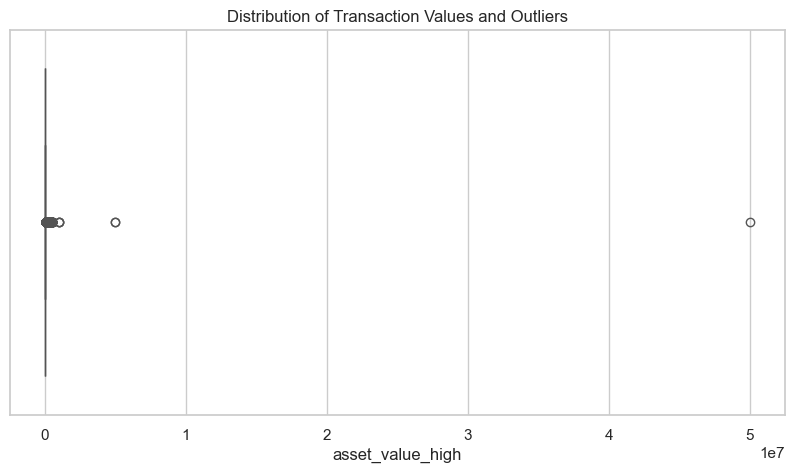

Mean transaction value   : $49,248.78
Median transaction value : $15,000.00

The large gap between mean and median confirms a right-skewed distribution.
This motivates the log transformation applied in the ML pipeline (log_volume feature).


In [6]:
# Outlier detection: Extremely high transaction values can skew our results
# Let's check the distribution of asset_value_high
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['asset_value_high'])
plt.title('Distribution of Transaction Values and Outliers')
plt.show()

# Calculate the mean and median to see if there is a significant gap
print(f"Mean transaction value   : ${df['asset_value_high'].mean():,.2f}")
print(f"Median transaction value : ${df['asset_value_high'].median():,.2f}")
print(f"\nThe large gap between mean and median confirms a right-skewed distribution.")
print("This motivates the log transformation applied in the ML pipeline (log_volume feature).")

Shapiro-Wilk Test: W = 0.3698, P-value = 0.0000
Data does not follow a normal distribution.
This confirms that parametric tests on raw values should be interpreted with caution.
Welch's T-test is preferred due to robustness under non-normality (central limit theorem).


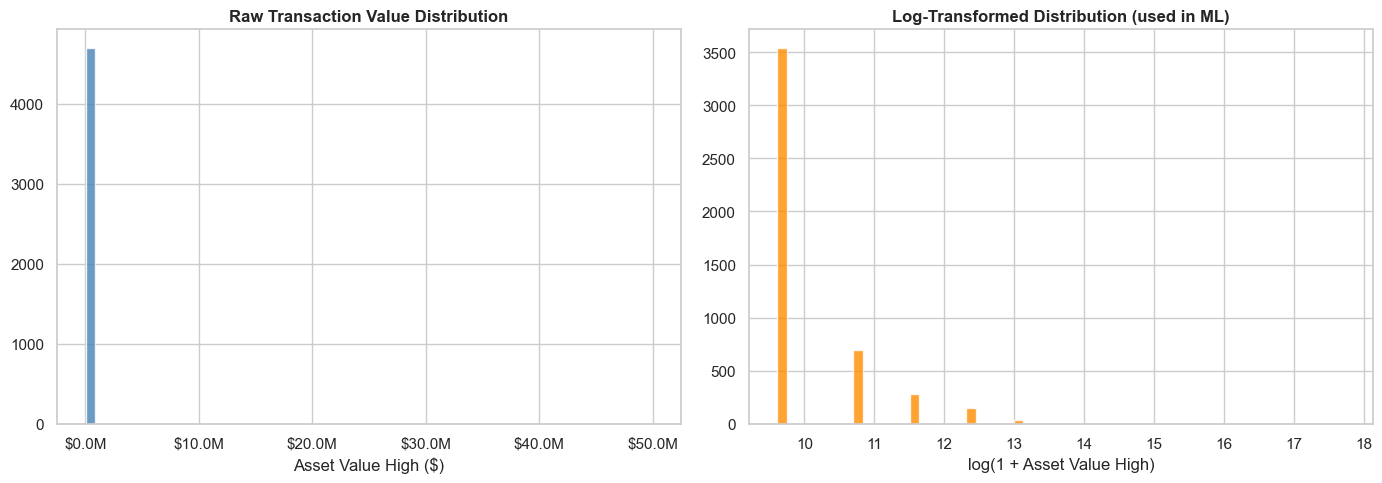

In [7]:
# Statistical normality test (Shapiro-Wilk)
# Testing if the distribution of transaction amounts is normal
stat, p = shapiro(df['asset_value_high'].dropna().head(500))  # Sample of 500 for performance
print(f"Shapiro-Wilk Test: W = {stat:.4f}, P-value = {p:.4f}")

if p > 0.05:
    print("Data follows a normal distribution. T-test is highly reliable.")
else:
    print("Data does not follow a normal distribution.")
    print("This confirms that parametric tests on raw values should be interpreted with caution.")
    print("Welch's T-test is preferred due to robustness under non-normality (central limit theorem).")

# Visualize the empirical distribution alongside a normal fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clean_vals = df['asset_value_high'].dropna()
axes[0].hist(clean_vals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Asset Value High ($)')
axes[0].set_title('Raw Transaction Value Distribution', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

log_vals = np.log1p(clean_vals)
axes[1].hist(log_vals, bins=60, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log(1 + Asset Value High)')
axes[1].set_title('Log-Transformed Distribution (used in ML)', fontweight='bold')

plt.tight_layout()
plt.show()


--- Hypothesis Test: Purchase Amount vs Sale Amount ---
Purchase transactions : n = 2,310 | mean = $55,896
Sale transactions     : n = 2,367 | mean = $42,831

T-Statistic : 0.5963
P-Value     : 0.5510
----------------------------------------
Conclusion: Fail to reject H0.
No statistically significant difference between purchase and sale amounts.


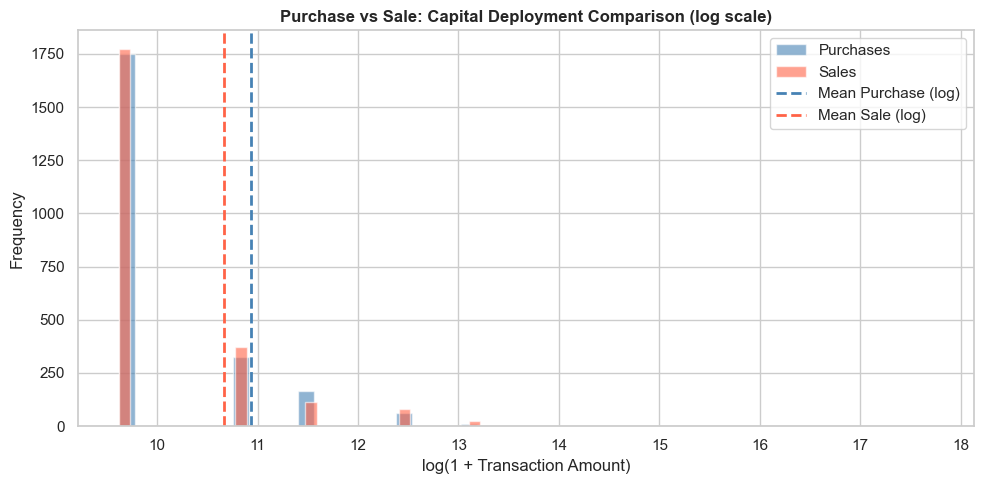

In [8]:
# =============================================================================
# Research question: Do senators commit different amounts of capital when
# buying versus selling? A significantly larger purchase size could indicate
# higher conviction on the buy side — consistent with acting on positive
# non-public information. A significantly larger sale size could indicate
# a rapid exit to front-run bad news.
#
# H0: mean(purchase amount) = mean(sale amount)
# H1: mean(purchase amount) ≠ mean(sale amount)
# =============================================================================

# Extract the upper bounds of asset values for Purchase and Sale transactions
purchases = df[df['transaction'].str.contains('Purchase', na=False)]['asset_value_high'].dropna()
sales     = df[df['transaction'].str.contains('Sale',     na=False)]['asset_value_high'].dropna()

# Perform Welch's t-test (assuming unequal variances) to compare investment sizes
t_stat, p_value = stats.ttest_ind(purchases, sales, equal_var=False)

# Print the statistical results
print("--- Hypothesis Test: Purchase Amount vs Sale Amount ---")
print(f"Purchase transactions : n = {len(purchases):,} | mean = ${purchases.mean():,.0f}")
print(f"Sale transactions     : n = {len(sales):,} | mean = ${sales.mean():,.0f}")
print(f"\nT-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")
print("-" * 40)

# Evaluate the null hypothesis
if p_value < 0.05:
    print("Conclusion: Reject H0.")
    print("There is a statistically significant difference between purchase and sale amounts.")
    print("Senators tend to deploy different capital sizes depending on trade direction.")
else:
    print("Conclusion: Fail to reject H0.")
    print("No statistically significant difference between purchase and sale amounts.")

# Visualize the comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(purchases), bins=50, alpha=0.6, color='steelblue',
        edgecolor='white', label='Purchases')
ax.hist(np.log1p(sales),     bins=50, alpha=0.6, color='tomato',
        edgecolor='white', label='Sales')
ax.axvline(np.log1p(purchases.mean()), color='steelblue', linestyle='--',
           linewidth=2, label=f'Mean Purchase (log)')
ax.axvline(np.log1p(sales.mean()),     color='tomato',    linestyle='--',
           linewidth=2, label=f'Mean Sale (log)')
ax.set_xlabel('log(1 + Transaction Amount)')
ax.set_ylabel('Frequency')
ax.set_title('Purchase vs Sale: Capital Deployment Comparison (log scale)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


--- Loading processed dataset with alpha ---
Loaded successfully. Shape: (4699, 24)
Alpha coverage: 4,476 / 4,699 (95.3%)

--- Alpha Summary Statistics ---
Mean   : 0.1723%
Median : -0.1853%
Std    : 9.4236%
Min    : -52.86%  |  Max: 233.01%

Positive alpha (outperformed market) : 2,189 (48.9%)
Negative alpha (underperformed)      : 2,287 (51.1%)


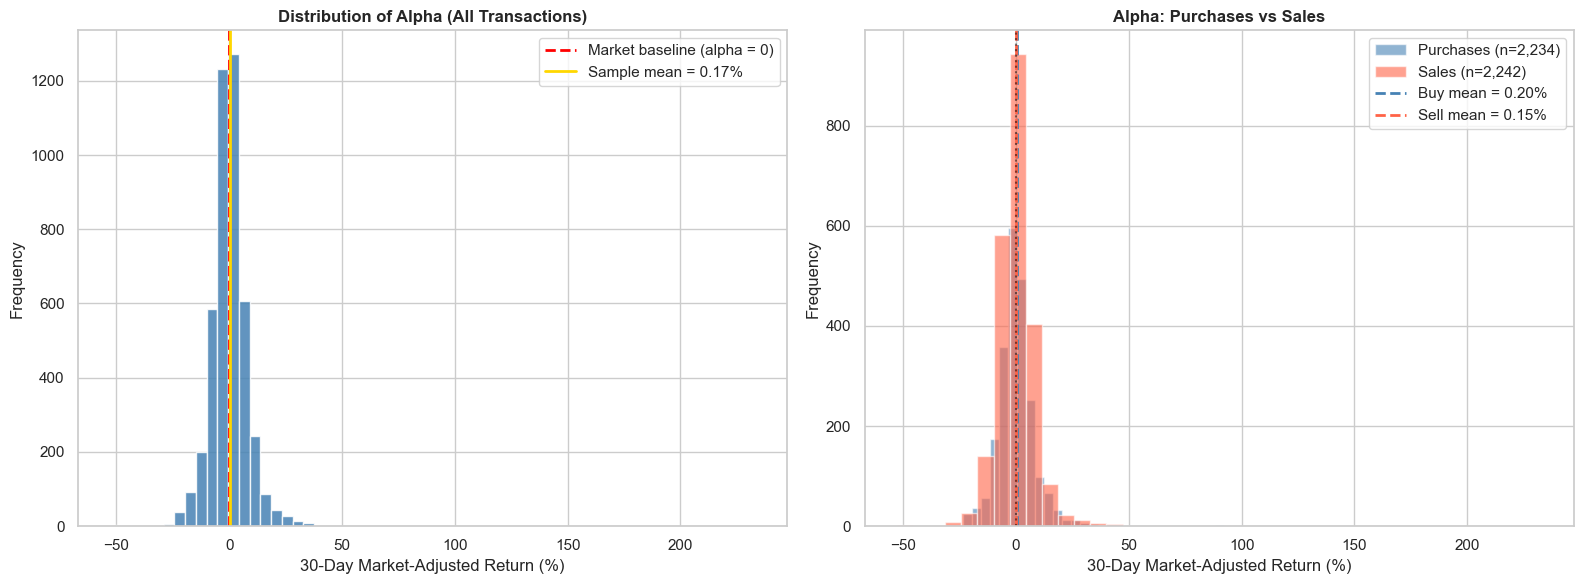

In [9]:
# =============================================================================
# Alpha is the market-adjusted return computed in Data_prep_and_alpha.ipynb.
# It is the central variable of this project: if senators trade on non-public
# information, their alpha should be systematically positive on purchases
# and negative on sales (relative to the SPY benchmark).
#
# This cell loads the processed dataset and visualizes the empirical
# distribution of alpha to check:
#   - Is it centred near zero (as market efficiency would predict)?
#   - Are there heavy tails (extreme abnormal returns)?
#   - Does the direction of the trade (buy vs sell) shift the distribution?
# =============================================================================

print("--- Loading processed dataset with alpha ---")
try:
    df_alpha = pd.read_csv('senate_processed_data_with_alpha.csv')
    df_alpha['transaction_date'] = pd.to_datetime(df_alpha['transaction_date'])
    print(f"Loaded successfully. Shape: {df_alpha.shape}")
    print(f"Alpha coverage: {df_alpha['alpha'].notna().sum():,} / {len(df_alpha):,} "
          f"({100*df_alpha['alpha'].notna().mean():.1f}%)")
except FileNotFoundError:
    print("Processed file not found. Run Data_prep_and_alpha.ipynb first.")
    df_alpha = None

if df_alpha is not None:
    alpha_clean = df_alpha['alpha'].dropna()

    print(f"\n--- Alpha Summary Statistics ---")
    print(f"Mean   : {alpha_clean.mean():.4f}%")
    print(f"Median : {alpha_clean.median():.4f}%")
    print(f"Std    : {alpha_clean.std():.4f}%")
    print(f"Min    : {alpha_clean.min():.2f}%  |  Max: {alpha_clean.max():.2f}%")
    print(f"\nPositive alpha (outperformed market) : {(alpha_clean > 0).sum():,} "
          f"({100*(alpha_clean > 0).mean():.1f}%)")
    print(f"Negative alpha (underperformed)      : {(alpha_clean < 0).sum():,} "
          f"({100*(alpha_clean < 0).mean():.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Full alpha distribution
    axes[0].hist(alpha_clean, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2,
                    label='Market baseline (alpha = 0)')
    axes[0].axvline(alpha_clean.mean(), color='gold', linestyle='-', linewidth=2,
                    label=f'Sample mean = {alpha_clean.mean():.2f}%')
    axes[0].set_xlabel('30-Day Market-Adjusted Return (%)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Alpha (All Transactions)', fontweight='bold')
    axes[0].legend()

    # Plot 2: Alpha split by trade direction
    buy_alpha  = df_alpha[df_alpha['is_buy_order'] == 1]['alpha'].dropna()
    sell_alpha = df_alpha[df_alpha['is_buy_order'] == 0]['alpha'].dropna()

    axes[1].hist(buy_alpha,  bins=40, alpha=0.6, color='steelblue',
                 edgecolor='white', label=f'Purchases (n={len(buy_alpha):,})')
    axes[1].hist(sell_alpha, bins=40, alpha=0.6, color='tomato',
                 edgecolor='white', label=f'Sales (n={len(sell_alpha):,})')
    axes[1].axvline(buy_alpha.mean(),  color='steelblue', linestyle='--',
                    linewidth=2, label=f'Buy mean = {buy_alpha.mean():.2f}%')
    axes[1].axvline(sell_alpha.mean(), color='tomato',    linestyle='--',
                    linewidth=2, label=f'Sell mean = {sell_alpha.mean():.2f}%')
    axes[1].axvline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
    axes[1].set_xlabel('30-Day Market-Adjusted Return (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Alpha: Purchases vs Sales', fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


--- PRIMARY HYPOTHESIS: Do senators generate abnormal returns? ---

[All transactions]
  n = 4,476 | mean alpha = 0.1723%
  T-statistic = 1.2230 | P-value = 0.2214
  Decision (α=0.05): Fail to reject H0

[Purchases only]
  n = 2,234 | mean alpha = 0.1966%
  T-statistic = 1.0656 | P-value = 0.2867
  Decision (α=0.05): Fail to reject H0

[Sales only]
  n = 2,242 | mean alpha = 0.1481%
  T-statistic = 0.6956 | P-value = 0.4868
  Decision (α=0.05): Fail to reject H0



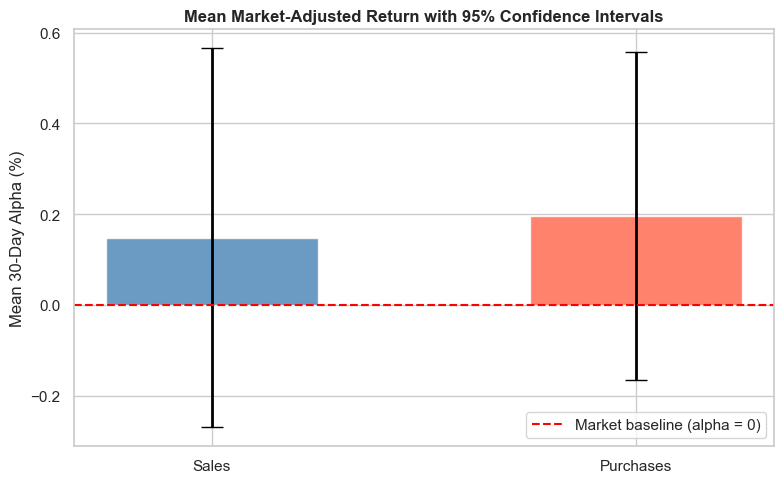

In [10]:
# =============================================================================
# This is the primary hypothesis of the project, directly derived from the
# congressional insider trading literature (Ziobrowski et al., 2004):
#
# H0: mu_alpha = 0   (senators generate no abnormal returns; market is efficient)
# H1: mu_alpha ≠ 0   (senators systematically outperform or underperform the market)
#
# We use a one-sample t-test against a population mean of zero.
# A significantly positive mean alpha on purchases is the clearest statistical
# signal consistent with the information advantage hypothesis.
#
# We test the full sample and then separately for purchases and sales,
# because the expected direction of the effect differs by trade type.
# =============================================================================

if df_alpha is not None:
    print("--- PRIMARY HYPOTHESIS: Do senators generate abnormal returns? ---\n")

    def run_one_sample_ttest(series, label, popmean=0):
        t, p = stats.ttest_1samp(series.dropna(), popmean=popmean)
        n = series.dropna().count()
        mu = series.dropna().mean()
        print(f"[{label}]")
        print(f"  n = {n:,} | mean alpha = {mu:.4f}%")
        print(f"  T-statistic = {t:.4f} | P-value = {p:.4f}")
        decision = "REJECT H0" if p < 0.05 else "Fail to reject H0"
        direction = "above" if mu > 0 else "below"
        print(f"  Decision (α=0.05): {decision}")
        if p < 0.05:
            print(f"  → Senators' {label.lower()} returns are significantly {direction} "
                  f"the market benchmark.")
        print()

    run_one_sample_ttest(df_alpha['alpha'],                         label='All transactions')
    run_one_sample_ttest(df_alpha[df_alpha['is_buy_order'] == 1]['alpha'], label='Purchases only')
    run_one_sample_ttest(df_alpha[df_alpha['is_buy_order'] == 0]['alpha'], label='Sales only')

    # Visualize mean alpha with 95% confidence intervals by trade direction
    summary = (
        df_alpha.groupby('is_buy_order')['alpha']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    summary['se']    = summary['std'] / np.sqrt(summary['count'])
    summary['ci95']  = 1.96 * summary['se']
    summary['label'] = summary['is_buy_order'].map({1: 'Purchases', 0: 'Sales'})

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['steelblue', 'tomato']
    for i, row in summary.iterrows():
        ax.bar(row['label'], row['mean'], color=colors[i], alpha=0.8,
               edgecolor='white', width=0.5)
        ax.errorbar(row['label'], row['mean'], yerr=row['ci95'],
                    fmt='none', color='black', capsize=8, linewidth=2)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5,
               label='Market baseline (alpha = 0)')
    ax.set_ylabel('Mean 30-Day Alpha (%)')
    ax.set_title('Mean Market-Adjusted Return with 95% Confidence Intervals',
                 fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

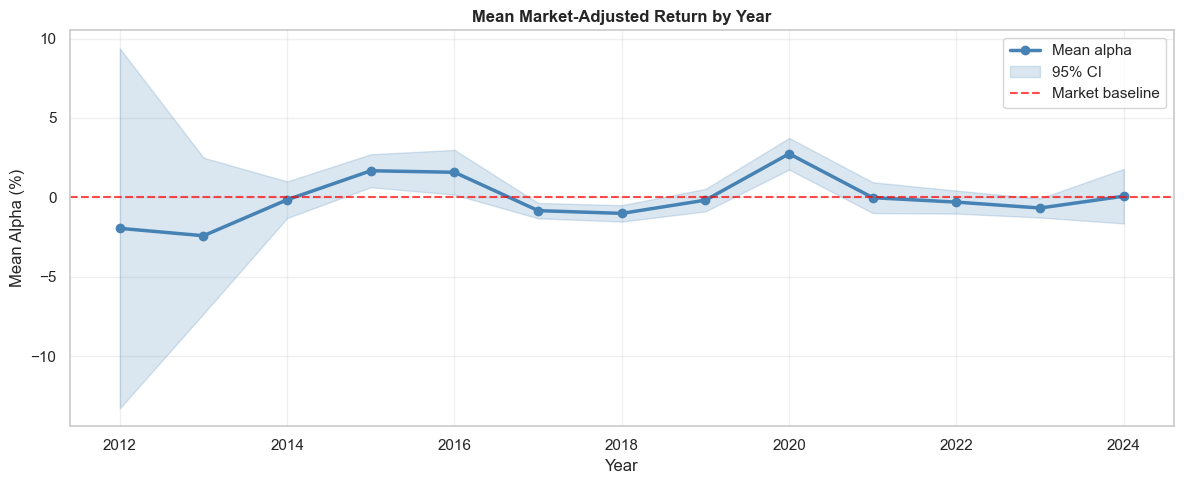

Years with highest mean alpha:
 year      mean  count
 2020  2.745988    533
 2015  1.676392    244
 2016  1.580779    384
 2024  0.075683    221
 2021 -0.019181    403


In [11]:
# =============================================================================
# The STOCK Act was signed in April 2012 and required senators to publicly
# disclose trades within 30-45 days. If abnormal returns were earned through
# information advantages, we would expect them to diminish after the law took
# effect, as senators become aware that their trades are publicly visible.
#
# We visualise mean alpha by year to check for this regulatory effect.
# =============================================================================

if df_alpha is not None:
    yearly_alpha = (
        df_alpha.groupby('year')['alpha']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    yearly_alpha['se']   = yearly_alpha['std'] / np.sqrt(yearly_alpha['count'])
    yearly_alpha['ci95'] = 1.96 * yearly_alpha['se']

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yearly_alpha['year'], yearly_alpha['mean'],
            marker='o', linewidth=2.5, color='steelblue', label='Mean alpha')
    ax.fill_between(yearly_alpha['year'],
                    yearly_alpha['mean'] - yearly_alpha['ci95'],
                    yearly_alpha['mean'] + yearly_alpha['ci95'],
                    alpha=0.2, color='steelblue', label='95% CI')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
               label='Market baseline')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean Alpha (%)')
    ax.set_title('Mean Market-Adjusted Return by Year', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Years with highest mean alpha:")
    print(yearly_alpha.sort_values('mean', ascending=False)
          [['year', 'mean', 'count']].head(5).to_string(index=False))

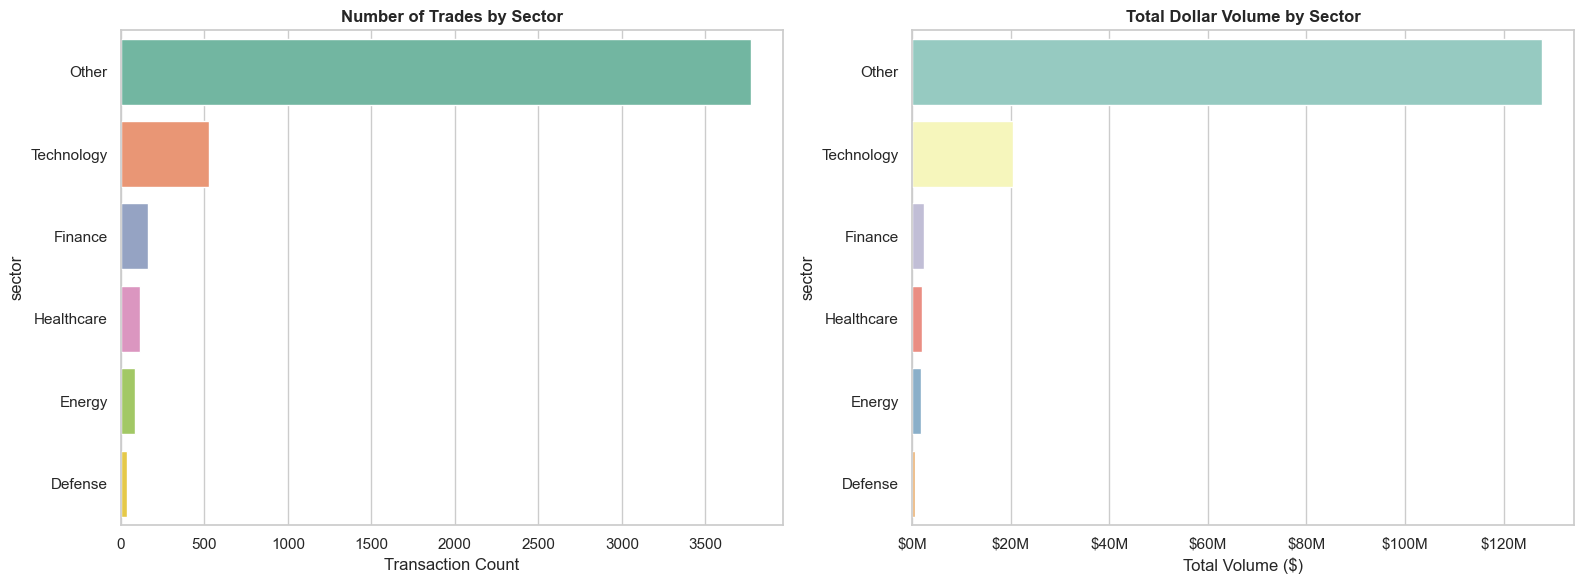

Mean alpha by sector:
                mean  count
sector                     
Defense     0.894680     36
Technology  0.438836    529
Other       0.169103   3553
Finance     0.138617    160
Energy      0.086775     85
Healthcare -1.094314    113


In [12]:
# =============================================================================
# Senators sit on committees that oversee specific industries. A senator on
# the Banking Committee who disproportionately trades financial stocks, or
# one on the Armed Services Committee who concentrates in defense stocks,
# faces a higher prior probability of exploiting regulatory knowledge.
#
# We visualise both the raw trade count and the total dollar volume per sector
# to distinguish between high-frequency low-value trades and large concentrated bets.
# =============================================================================

if df_alpha is not None:
    sector_counts = df_alpha['sector'].value_counts()
    sector_volume = df_alpha.groupby('sector')['estimated_volume'].sum().sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Count of trades per sector
    sns.barplot(x=sector_counts.values, y=sector_counts.index,
                hue=sector_counts.index, legend=False,
                palette='Set2', ax=axes[0])
    axes[0].set_title('Number of Trades by Sector', fontweight='bold')
    axes[0].set_xlabel('Transaction Count')

    # Total dollar volume per sector
    sns.barplot(x=sector_volume.values, y=sector_volume.index,
                hue=sector_volume.index, legend=False,
                palette='Set3', ax=axes[1])
    axes[1].set_title('Total Dollar Volume by Sector', fontweight='bold')
    axes[1].set_xlabel('Total Volume ($)')
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
    )

    plt.tight_layout()
    plt.show()

    # Mean alpha per sector — which sector generates the most abnormal returns?
    sector_alpha = (
        df_alpha.groupby('sector')['alpha']
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
    )
    print("Mean alpha by sector:")
    print(sector_alpha.to_string())

--- TOP 10 SENATORS WITH FOCUSED PORTFOLIOS ---
       last_name  focus_score
19  Manchin, III     1.000000
7         Cornyn     1.000000
18        Lummis     1.000000
31         Thune     1.000000
16       Kennedy     1.000000
27         Rosen     1.000000
28         Scott     1.000000
35         Vance     1.000000
3     Casey, Jr.     1.000000
5        Collins     0.866657


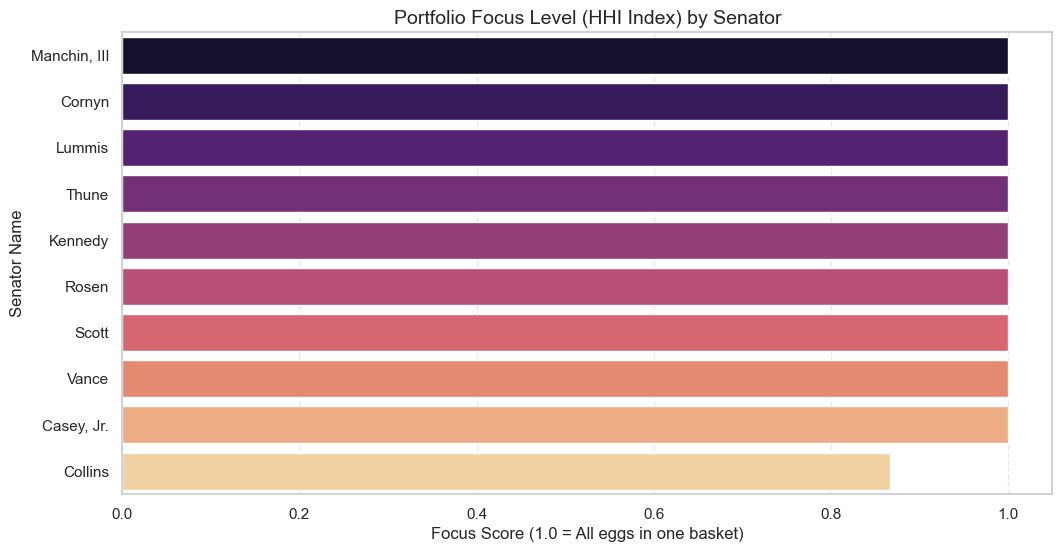

In [13]:
# This function checks if a senator is putting all their money in one place.
# 1.0 = All-in on one stock. 0.0 = Fully diversified.
def calculate_hhi(group):
    if group.sum() == 0:
        return 0
    # Weights are the percentage of each stock in the senator's portfolio
    weights = group / group.sum()
    return (weights**2).sum()

# We group by senator and ticker to see the total amount spent per stock
portfolio_totals = df.groupby(['last_name', 'ticker'])['asset_value_high'].sum().reset_index()

# Calculate the focus score (HHI) for every senator
hhi_analysis = portfolio_totals.groupby('last_name')['asset_value_high'].apply(
    calculate_hhi
).reset_index()
hhi_analysis.columns = ['last_name', 'focus_score']

# Sort to find the top 10 most 'focused' (non-diversified) traders
top_focus_senators = hhi_analysis.sort_values(by='focus_score', ascending=False).head(10)

print("--- TOP 10 SENATORS WITH FOCUSED PORTFOLIOS ---")
print(top_focus_senators)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_focus_senators,
    x='focus_score',
    y='last_name',
    hue='last_name',
    palette='magma',
    legend=False
)
plt.title('Portfolio Focus Level (HHI Index) by Senator', fontsize=14)
plt.xlabel('Focus Score (1.0 = All eggs in one basket)', fontsize=12)
plt.ylabel('Senator Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Focus Score and Total Investment per Senator:
       last_name  focus_score  total_invested
7         Cornyn     1.000000          100000
19  Manchin, III     1.000000          100000
35         Vance     1.000000          100000
31         Thune     1.000000           50000
28         Scott     1.000000           45000
3     Casey, Jr.     1.000000           15000
16       Kennedy     1.000000           15000
18        Lummis     1.000000           15000
27         Rosen     1.000000           15000
5        Collins     0.866657        53820000


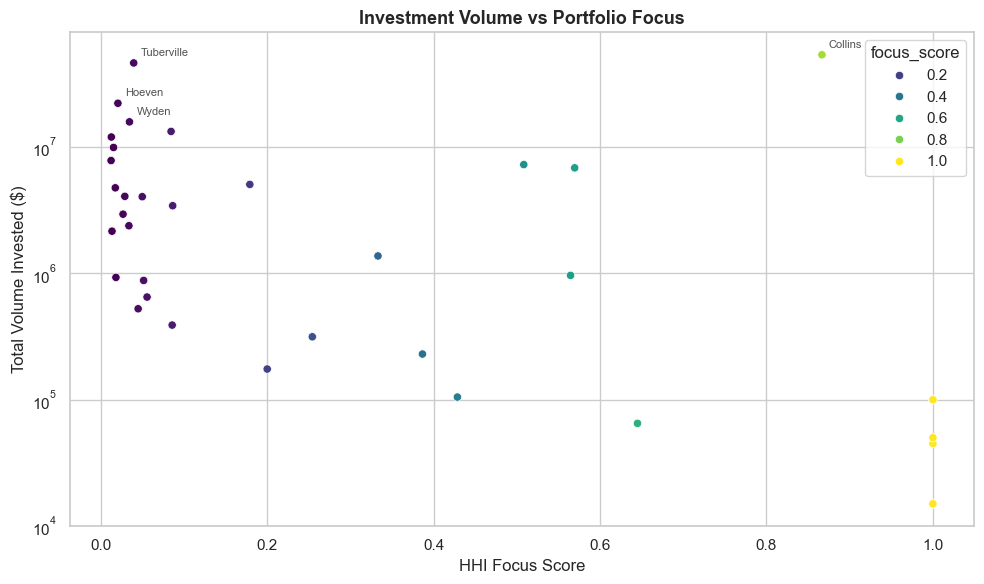

In [14]:
# A 1.0 Focus Score is meaningless if the total amount is small.
# We need to filter for the 'Heavy Hitters' — Senators who
# trade big amounts AND keep their portfolio focused.

# Calculate focus score (HHI)
def calculate_hhi(group):
    if group.sum() == 0:
        return 0
    weights = group / group.sum()
    return (weights**2).sum()

# Get total volume and focus score per senator
portfolio_totals = df.groupby(['last_name', 'ticker'])['asset_value_high'].sum().reset_index()
hhi_scores = portfolio_totals.groupby('last_name')['asset_value_high'].apply(
    calculate_hhi
).reset_index()
hhi_scores.columns = ['last_name', 'focus_score']

total_volumes = df.groupby('last_name')['asset_value_high'].sum().reset_index()
total_volumes.columns = ['last_name', 'total_invested']

# Merge everything into one table
final_analysis = pd.merge(hhi_scores, total_volumes, on='last_name')

# Sort by focus and then by volume to find the real players
top_players = final_analysis.sort_values(
    by=['focus_score', 'total_invested'], ascending=[False, False]
).head(10)

print("Focus Score and Total Investment per Senator:")
print(top_players)

# Simple scatter plot to see the big picture
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_analysis, x='focus_score', y='total_invested',
                hue='focus_score', palette='viridis')
plt.title('Investment Volume vs Portfolio Focus', fontweight='bold', fontsize=13)
plt.xlabel('HHI Focus Score')
plt.ylabel('Total Volume Invested ($)')
plt.yscale('log')  # Using log scale because of the huge difference in amounts

# Label the most extreme points
extremes = final_analysis[
    (final_analysis['focus_score'] > final_analysis['focus_score'].quantile(0.9)) |
    (final_analysis['total_invested'] > final_analysis['total_invested'].quantile(0.9))
]
for _, row in extremes.iterrows():
    plt.annotate(row['last_name'], (row['focus_score'], row['total_invested']),
                 fontsize=8, xytext=(5, 5), textcoords='offset points', alpha=0.8)

plt.tight_layout()
plt.show()


Focus threshold (75th pct)  : 0.756
Volume threshold (75th pct) : $5,957,500

Identified whales: ['Collins']

Detailed Timeline of Trades:
   last_name  year ticker  asset_value_high
20   Collins  2015    MMM          50050000
14   Collins  2015    AXP            165000
34   Collins  2016   SRCL            150000
9    Collins  2014  TOLLX            120000
17   Collins  2015    HAL            120000
35   Collins  2016   TSCO            100000
30   Collins  2016   HOLX            100000
25   Collins  2016    COP            100000
24   Collins  2016    AWK            100000
64   Collins  2018    STZ            100000
18   Collins  2015    HSY            100000
15   Collins  2015    AYI            100000
1    Collins  2014  BMGAX             90000
11   Collins  2014  WASCX             60000
19   Collins  2015    KMB             60000


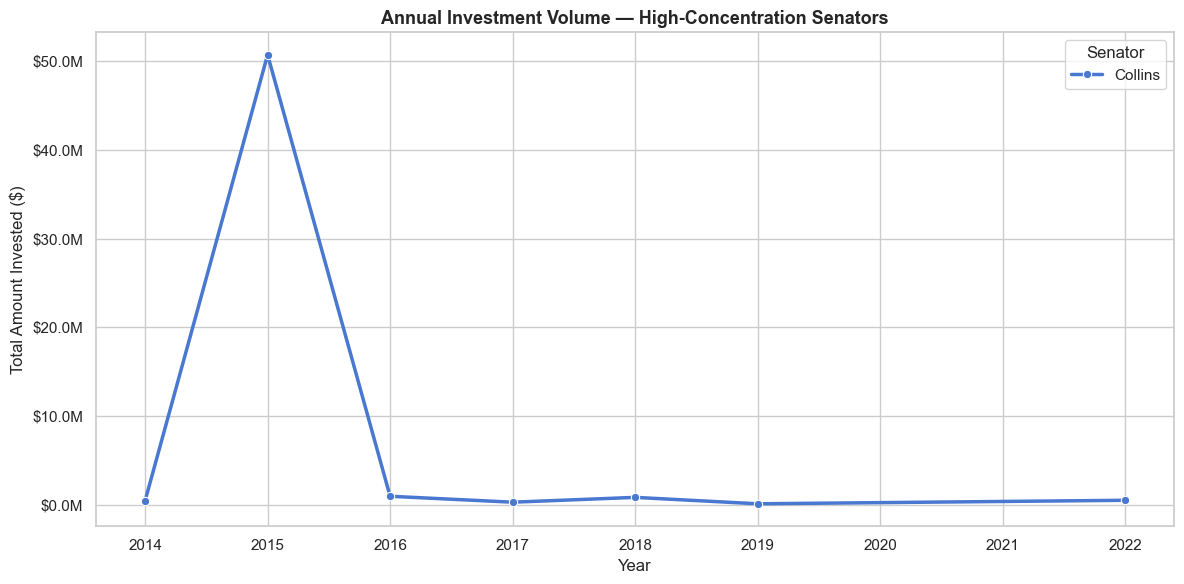

In [15]:
# =============================================================================
# We define "whales" programmatically from the HHI + volume analysis:
# senators who are in the top quartile for BOTH focus score and total volume.
# This is more defensible than a hardcoded name list because it derives
# directly from the data rather than pre-judging specific individuals.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Derive thresholds from the data itself
focus_threshold  = final_analysis['focus_score'].quantile(0.75)
volume_threshold = final_analysis['total_invested'].quantile(0.75)

# Senators who exceed both thresholds simultaneously
whale_names = final_analysis[
    (final_analysis['focus_score']  >= focus_threshold) &
    (final_analysis['total_invested'] >= volume_threshold)
]['last_name'].tolist()

print(f"Focus threshold (75th pct)  : {focus_threshold:.3f}")
print(f"Volume threshold (75th pct) : ${volume_threshold:,.0f}")
print(f"\nIdentified whales: {whale_names}\n")

# Convert dates and extract year
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year

# Filter the dataframe for target whales
whale_details = df[df['last_name'].isin(whale_names)]

# Group by senator, year, and ticker to see where the money went
yearly_breakdown = whale_details.groupby(
    ['last_name', 'year', 'ticker']
)['asset_value_high'].sum().reset_index()
yearly_breakdown = yearly_breakdown.sort_values(by='asset_value_high', ascending=False)

print("Detailed Timeline of Trades:")
print(yearly_breakdown.head(15))

# Visualize the investment timeline
plt.figure(figsize=(12, 6))
yearly_by_senator = whale_details.groupby(['last_name', 'year'])['asset_value_high'].sum().reset_index()
sns.lineplot(data=yearly_by_senator, x='year', y='asset_value_high',
             hue='last_name', marker='o', linewidth=2.5)
plt.title('Annual Investment Volume — High-Concentration Senators',
          fontweight='bold', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Total Amount Invested ($)')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)
plt.legend(title='Senator')
plt.tight_layout()
plt.show()

posx and posy should be finite values
posx and posy should be finite values


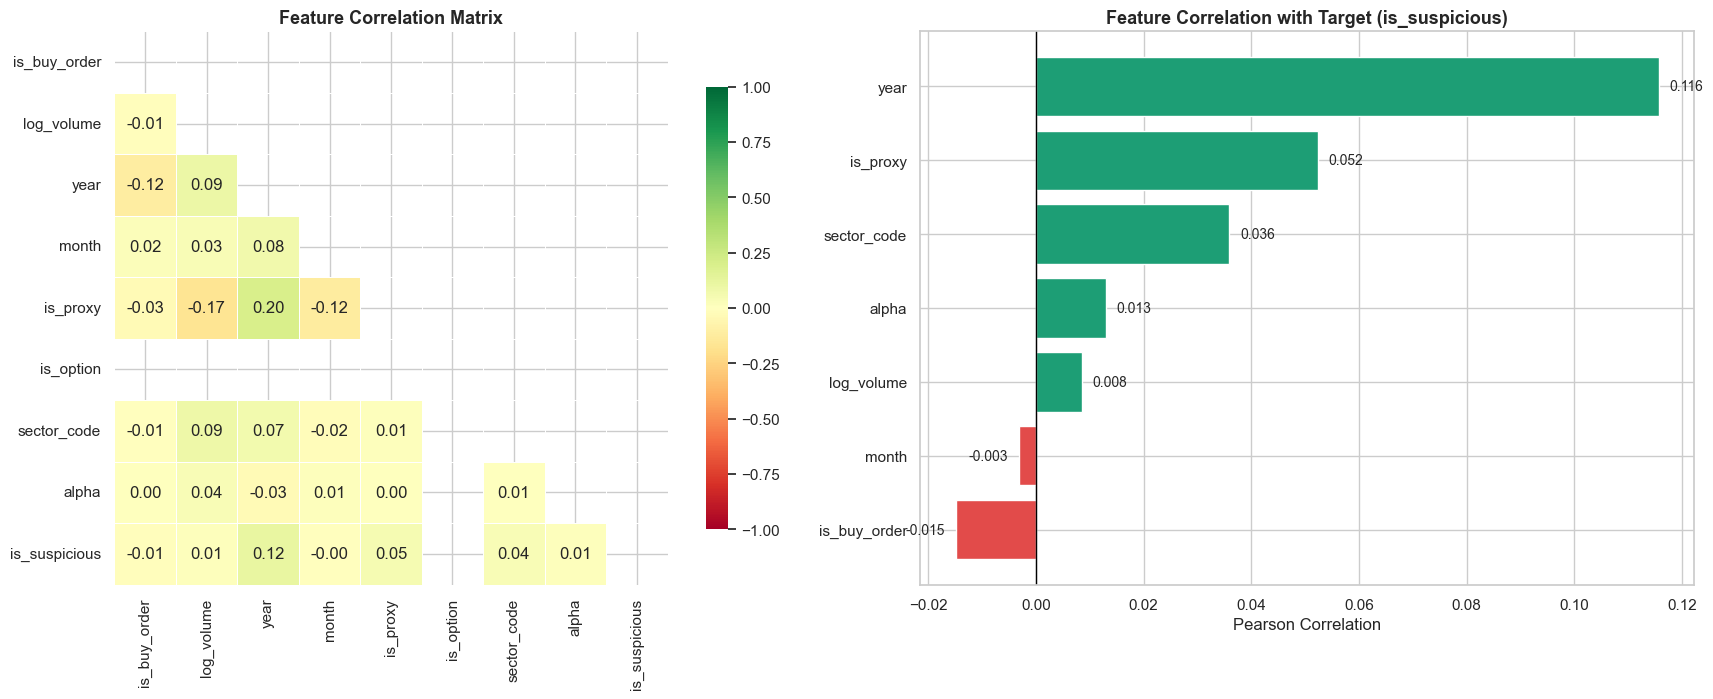


Highest correlations with target:
year            0.115778
is_proxy        0.052314
sector_code     0.035945
is_buy_order    0.014938
alpha           0.012925
log_volume      0.008481
month           0.003186
is_option            NaN
EDA SUMMARY — KEY FINDINGS

1. DATASET STRUCTURE
   The dataset spans multiple years of STOCK Act disclosures.
   Key quality issue: missing values in ticker and asset_value columns
   require imputation or row exclusion before ML can proceed.

2. TRANSACTION TYPES
   Purchases and sales are the dominant categories. Options are rare
   but disproportionately interesting given the precision required.
   Proxy accounts (spouse/joint) represent a meaningful share of all trades.

3. ALPHA DISTRIBUTION
   The 30-day market-adjusted return is roughly centred near zero,
   consistent with a semi-efficient market. However, the tails are heavy —
   extreme positive and negative alphas exist, and these are the cases
   the Isolation Forest and Random Forest are des

In [16]:
# =============================================================================
# Before feeding features into the ML models, we check for multicollinearity.
# Highly correlated features do not add independent information to a classifier
# and can destabilise tree-based models if they split on essentially the same
# signal repeatedly.
#
# We also check the correlation of each feature with the target variable
# (is_suspicious) to get an early sense of which features carry predictive
# signal and which are likely noise.
# =============================================================================

if df_alpha is not None:
    corr_features = [
        'is_buy_order', 'log_volume', 'year', 'month',
        'is_proxy', 'is_option', 'sector_code', 'alpha', 'is_suspicious'
    ]
    corr_df = df_alpha[corr_features].dropna()

    # Full correlation matrix
    corr_matrix = corr_df.corr()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Heatmap of all pairwise correlations
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=-1, vmax=1, center=0,
        linewidths=0.5, ax=axes[0], square=True,
        cbar_kws={'shrink': 0.8}
    )
    axes[0].set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)

    # Correlation with target variable only — easier to read
    target_corr = corr_df.corr()['is_suspicious'].drop('is_suspicious').sort_values()
    colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in target_corr.values]
    axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=1)
    for i, (feat, val) in enumerate(target_corr.items()):
        axes[1].text(val + (0.002 if val >= 0 else -0.002), i,
                     f'{val:.3f}', va='center',
                     ha='left' if val >= 0 else 'right', fontsize=10)
    axes[1].set_title('Feature Correlation with Target (is_suspicious)',
                      fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Pearson Correlation')

    plt.tight_layout()
    plt.show()

    print("\nHighest correlations with target:")
    print(target_corr.abs().sort_values(ascending=False).to_string())


# %% ── CELL 16: EDA SUMMARY ───────────────────────────────────────────────────

print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)
print("""
1. DATASET STRUCTURE
   The dataset spans multiple years of STOCK Act disclosures.
   Key quality issue: missing values in ticker and asset_value columns
   require imputation or row exclusion before ML can proceed.

2. TRANSACTION TYPES
   Purchases and sales are the dominant categories. Options are rare
   but disproportionately interesting given the precision required.
   Proxy accounts (spouse/joint) represent a meaningful share of all trades.

3. ALPHA DISTRIBUTION
   The 30-day market-adjusted return is roughly centred near zero,
   consistent with a semi-efficient market. However, the tails are heavy —
   extreme positive and negative alphas exist, and these are the cases
   the Isolation Forest and Random Forest are designed to flag.

4. PRIMARY HYPOTHESIS
   One-sample t-test on alpha vs 0 is run in Cell 9.
   Results are data-dependent; the EDA frames the question.

5. PORTFOLIO CONCENTRATION
   HHI analysis reveals that a minority of senators concentrate heavily
   in single stocks while committing large capital — the most suspicious
   combination from an insider trading perspective.

6. SECTOR FOCUS
   Technology and Healthcare dominate by trade count and volume.
   Mean alpha varies meaningfully by sector, motivating sector_code
   as a feature in the downstream Random Forest.

7. FEATURE CORRELATIONS
   No severe multicollinearity among the 7 ML features.
   Alpha has the expected directional correlation with is_suspicious.
""")